In [30]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

In [31]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


In [32]:
dataset = pd.read_csv("Attrition-RH-Data.csv")

In [33]:
dataset.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [34]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [35]:
dataset.isnull().sum().sum()


0

In [36]:
dataset.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


# 1.Suppression des variables inutiles


In [37]:
data = dataset.copy()

In [38]:
cols_to_drop = ['EmployeeCount','EmployeeNumber','Over18','StandardHours']
data = data.drop(columns=cols_to_drop)


In [39]:
Nc = len(data.columns)
print (f"Number of columns in the dataset after dropping useless columns: {Nc}")


Number of columns in the dataset after dropping useless columns: 31


# 2. EDA avec Seaborn

## *distrubtion de la variable cible*

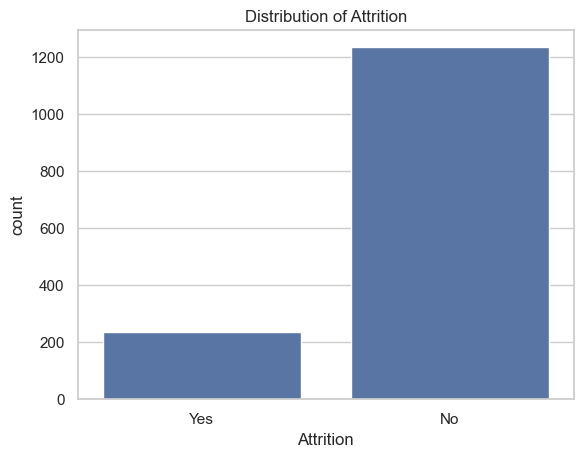

In [40]:
sns.countplot(x='Attrition', data=data)
plt.title("Distribution of Attrition")
plt.show()

### **D'aprés le graphe la dataset est déséquilibree**

## ***Variables Numeriques***

In [41]:
df_numeric = data.select_dtypes(include='number')
print(df_numeric.columns.tolist())

['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [42]:
numeric_cols = df_numeric.columns.tolist()
numeric_cols

['Age',
 'DailyRate',
 'DistanceFromHome',
 'Education',
 'EnvironmentSatisfaction',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobSatisfaction',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

### **Dans notre Dataset les variables ordinales initialement catégorielles ont été explicitement exclues afin d’éviter des interprétations statistiques trompeuses.**


In [43]:
ordinal_cols = [
    'Education',
    'EnvironmentSatisfaction',
    'JobInvolvement',
    'JobSatisfaction',
    'PerformanceRating',
    'RelationshipSatisfaction',
    'WorkLifeBalance',
    'JobLevel',
    'StockOptionLevel'
]


In [44]:
# Exclure les ordinals variables 
df_numeric= df_numeric.drop(columns=ordinal_cols)
numeric_cols = df_numeric.columns.tolist()
numeric_cols

['Age',
 'DailyRate',
 'DistanceFromHome',
 'HourlyRate',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

### Distrubtion Variables Numeriques 

In [45]:
# Fonction pour tracer hisplot entre variables numerique et la cible(Attrition)
def plot_Numeric_dis(df,feature,target='Atrrition'):
    sns.histplot(data=df,x=feature,hue=target, bins=20,kde=True)
    plt.title(f"Distribution de {feature} selon {target}")
    plt.show()


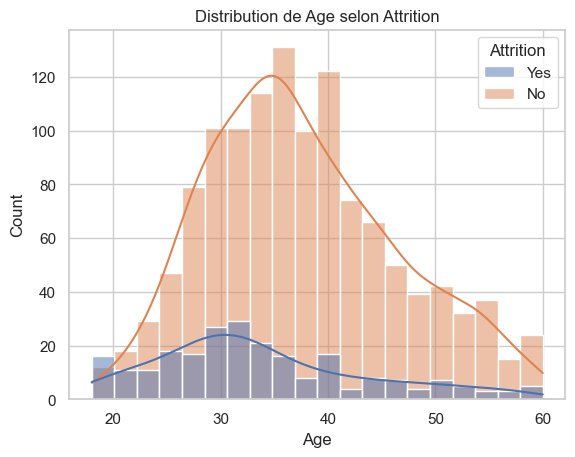

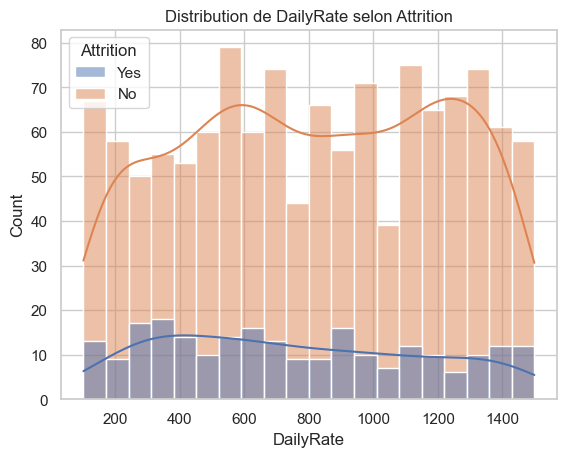

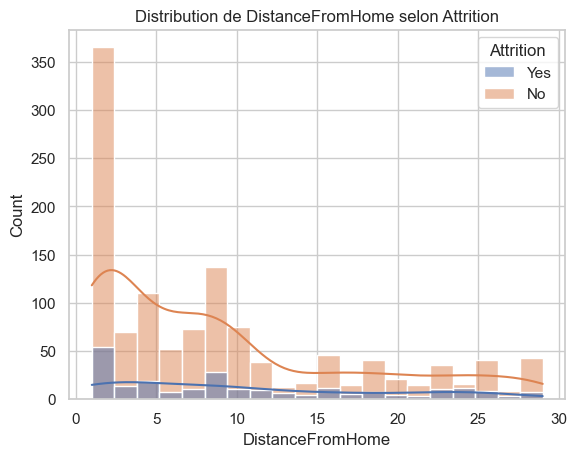

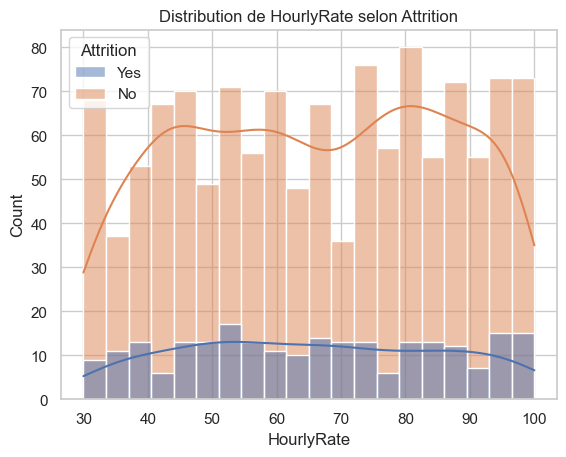

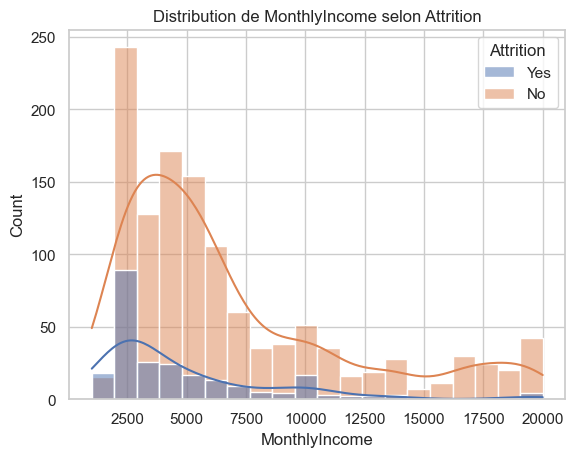

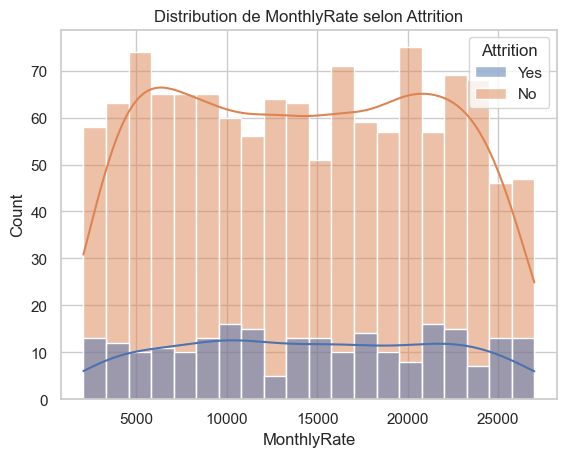

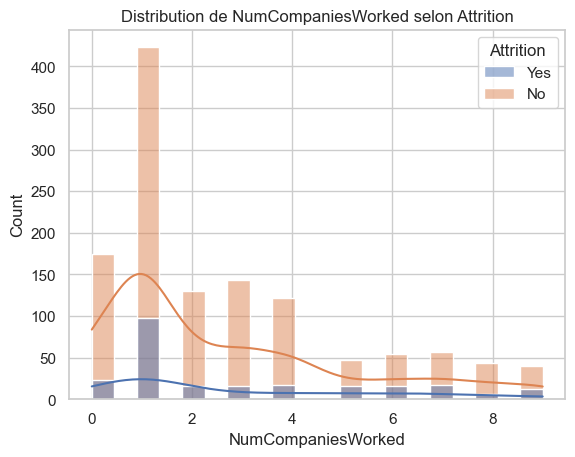

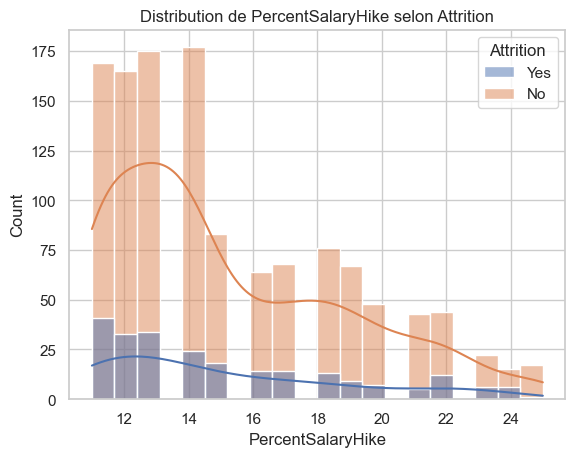

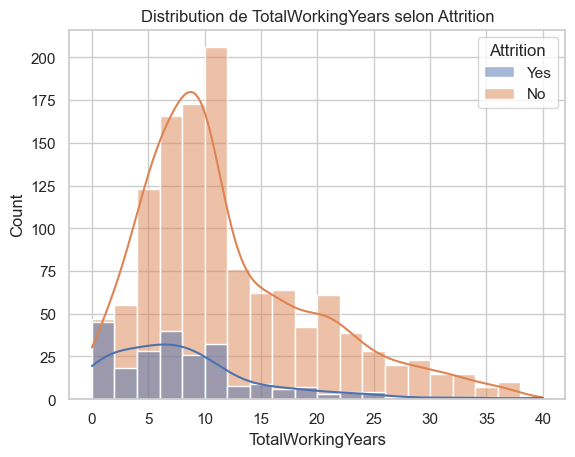

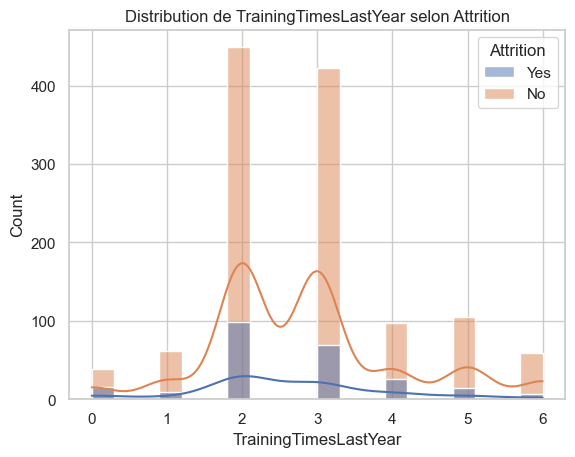

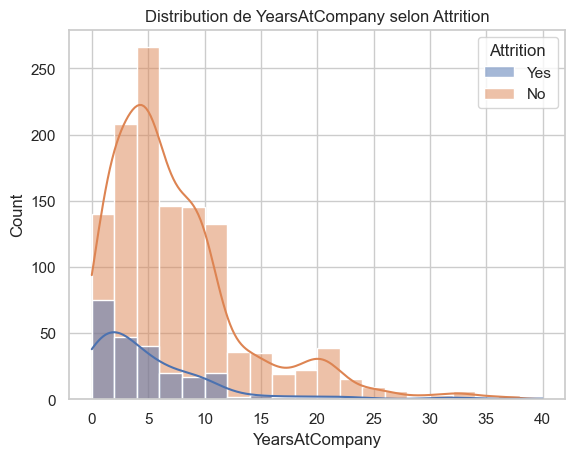

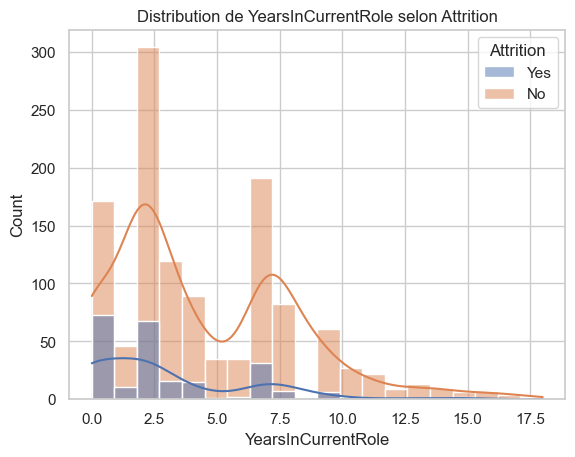

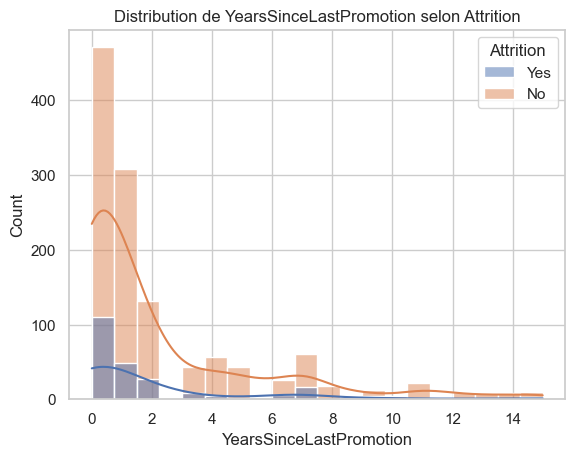

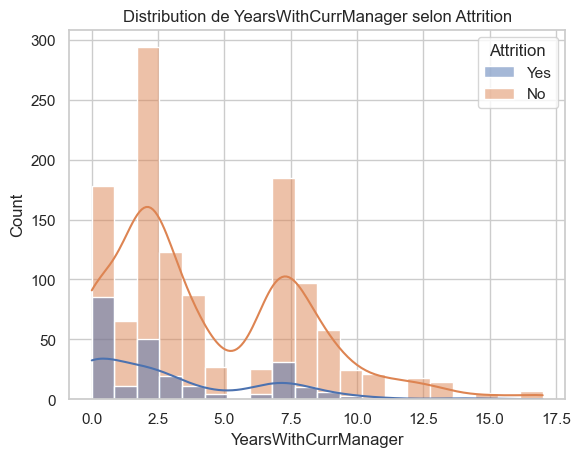

In [46]:
# Taraçage des des graphes pour tout les variables 
for col in numeric_cols:
    plot_Numeric_dis(data, col, target='Attrition')

In [47]:
# Trace un boxplot d'une variable numérique groupée par une variable catégorielle.
def plot_Numeric_boxplot(df,feature,target='Atrrition'):
    sns.boxplot(x=target, y=feature,data=df, palette='Set2')
    plt.title(f"Distribution de {feature} selon {target}")
    plt.show()

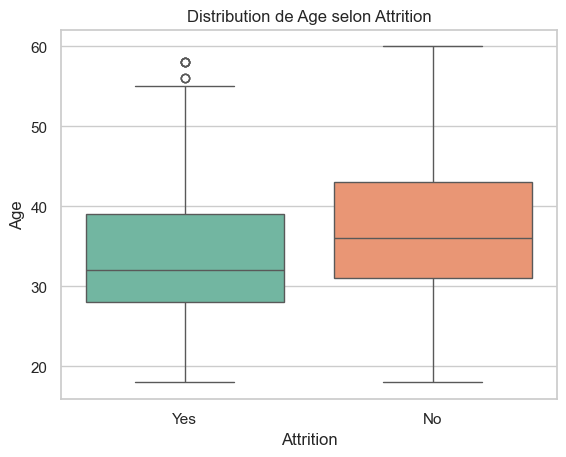

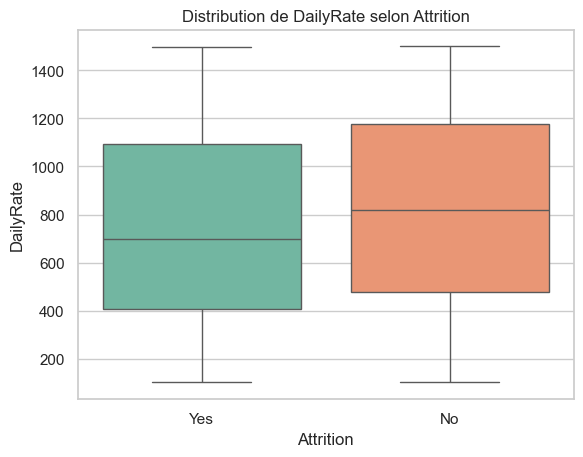

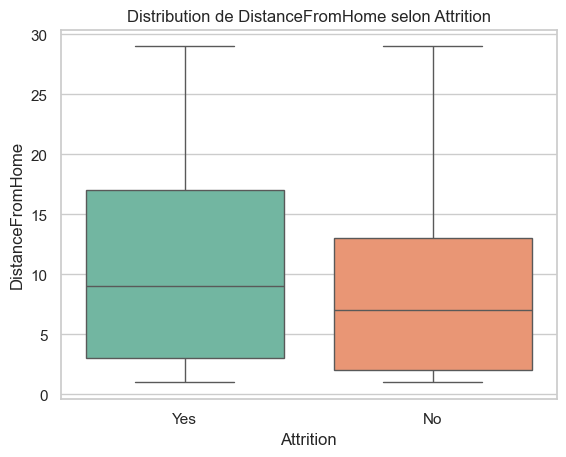

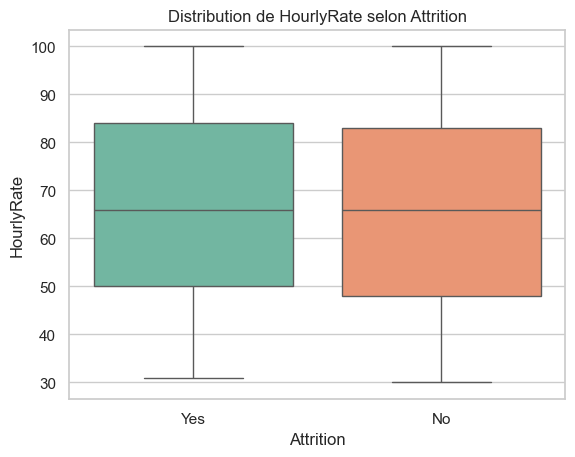

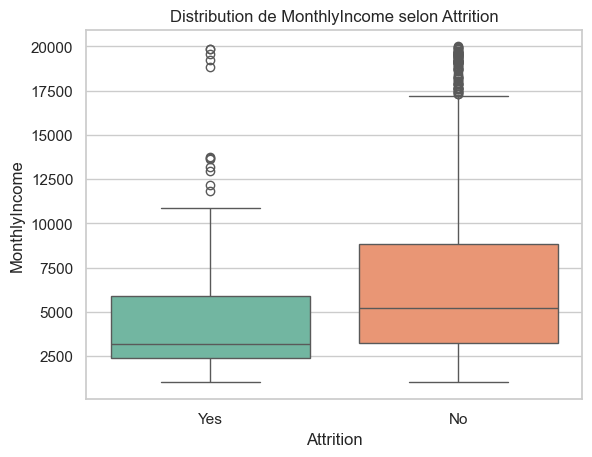

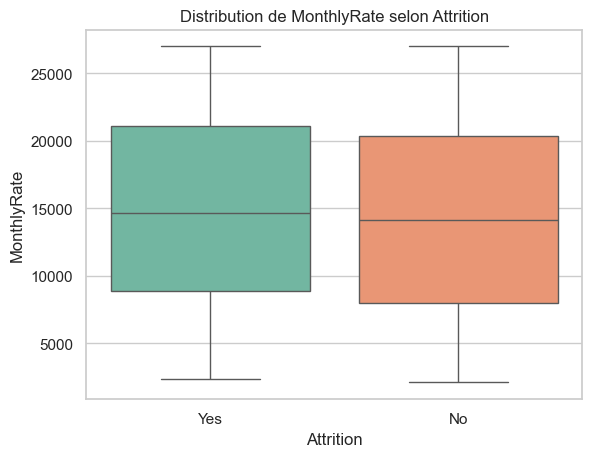

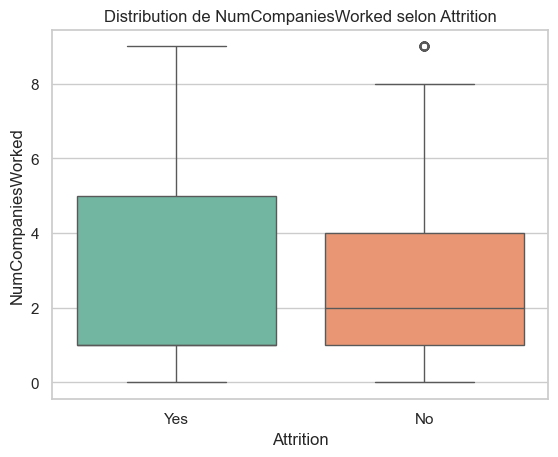

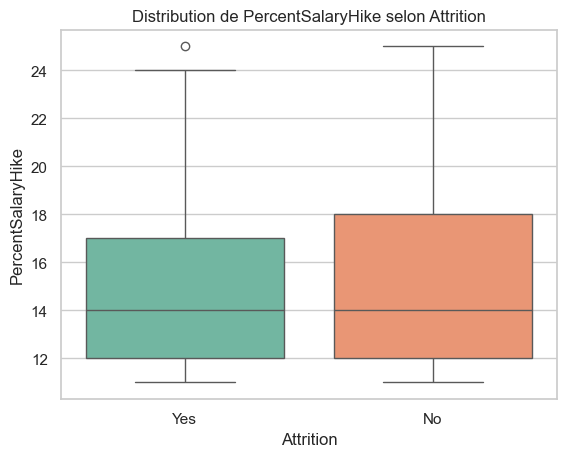

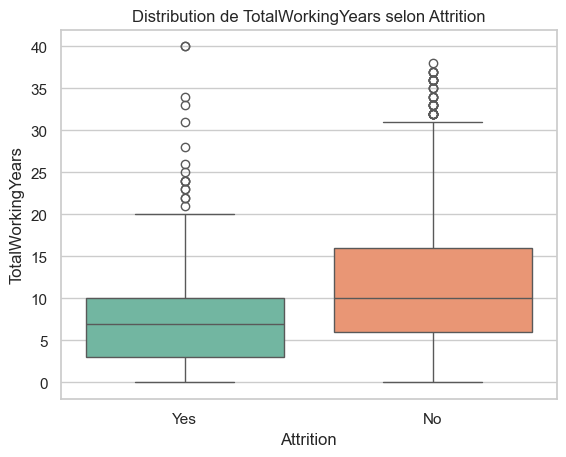

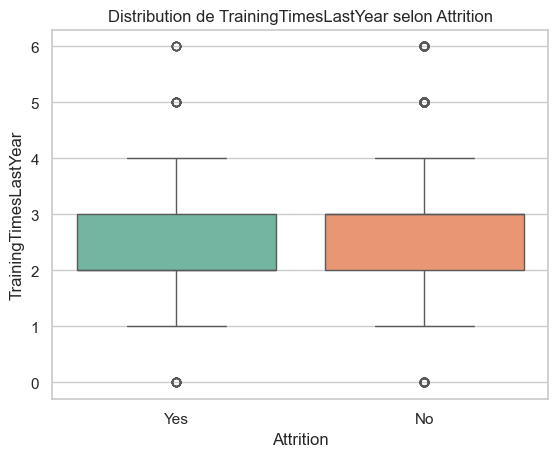

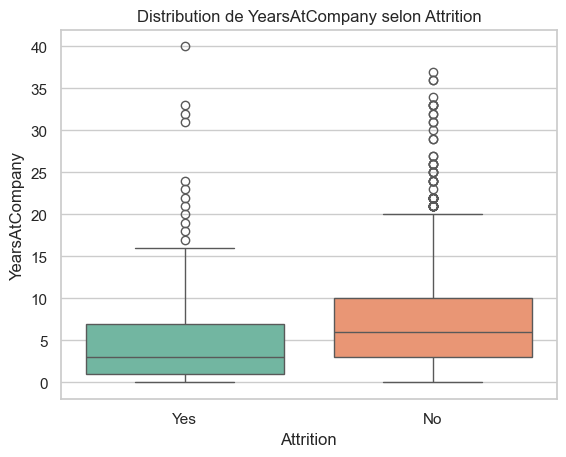

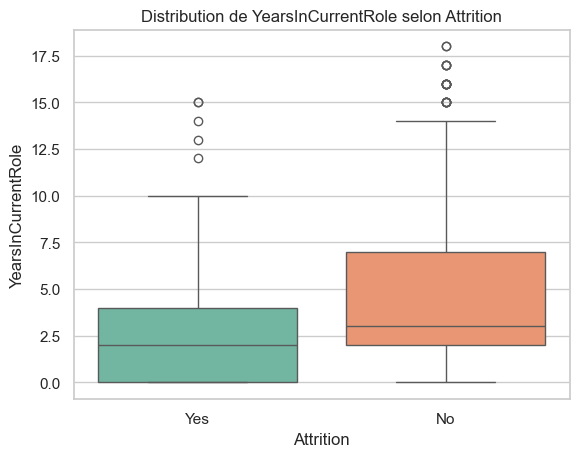

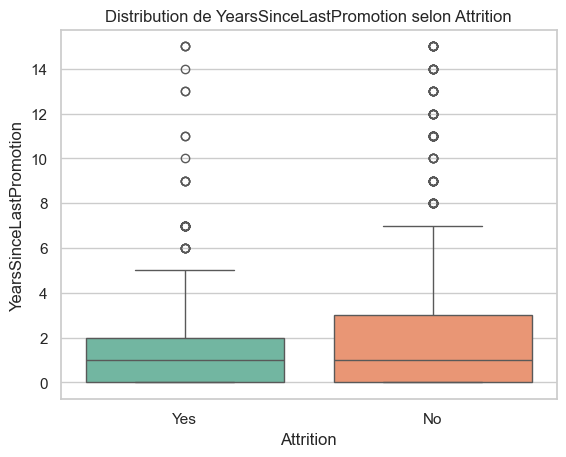

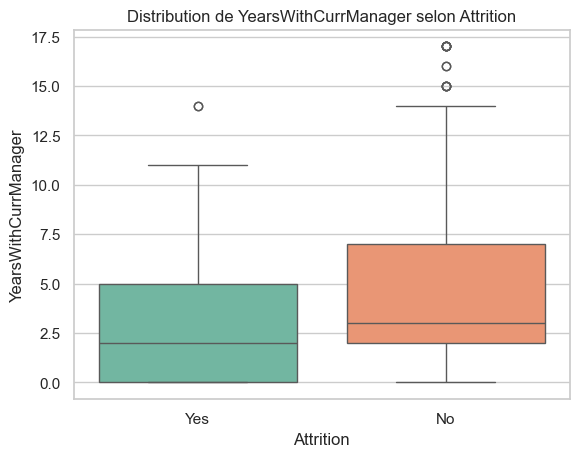

In [48]:
# Taraçage des des graphes pour tout les variables 
for col in numeric_cols:
    plot_Numeric_boxplot(data, col, target='Attrition')

### ***Variables Catégorielle***

In [49]:
df_categ = data.drop(columns=numeric_cols)
catg_cols = df_categ.columns.tolist()
catg_cols


['Attrition',
 'BusinessTravel',
 'Department',
 'Education',
 'EducationField',
 'EnvironmentSatisfaction',
 'Gender',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'OverTime',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StockOptionLevel',
 'WorkLifeBalance']

In [50]:
# Trace un countplot d'une variable catégorielle groupée par une variable catégorielle.
def plot_categ_count(df,feature,target='Attrition'):
    if feature == target:
        return
    sns.countplot(x=feature, hue=target, data=df, palette='Set2')
    plt.title(f"Répartition de {feature} selon {target}")
    plt.show()

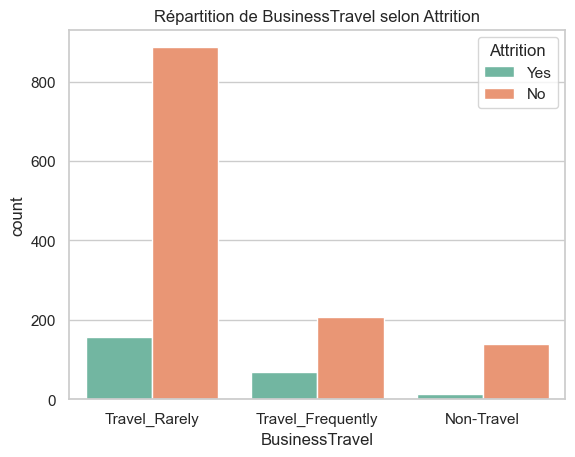

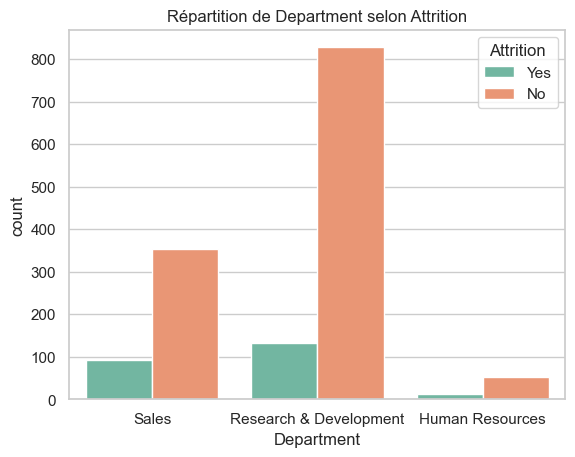

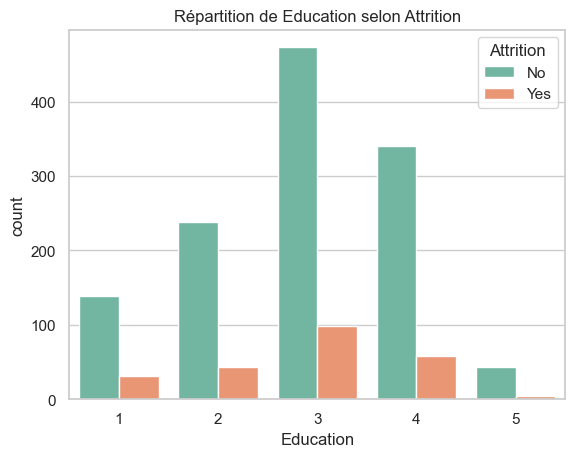

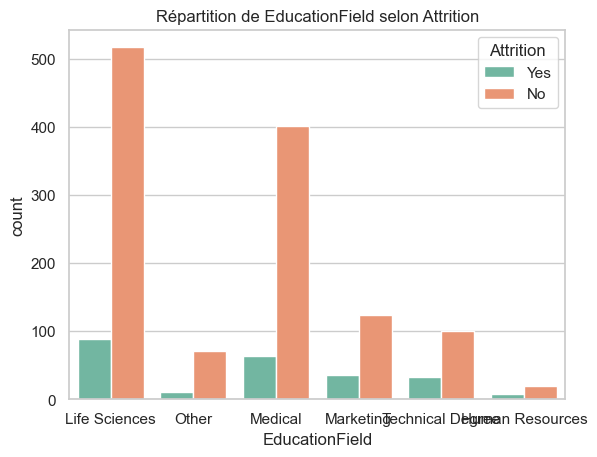

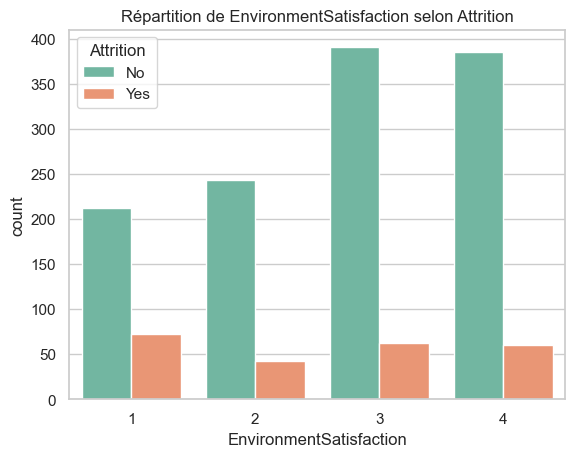

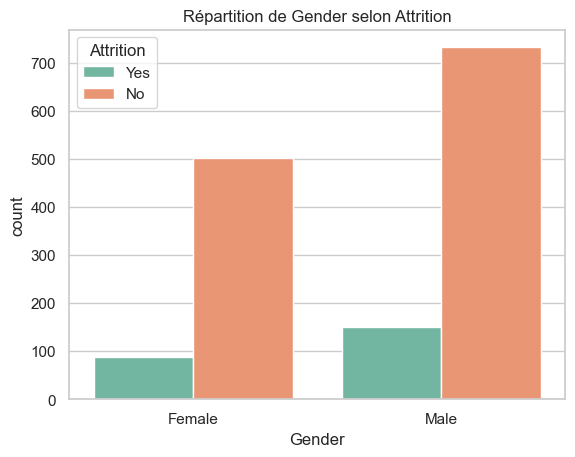

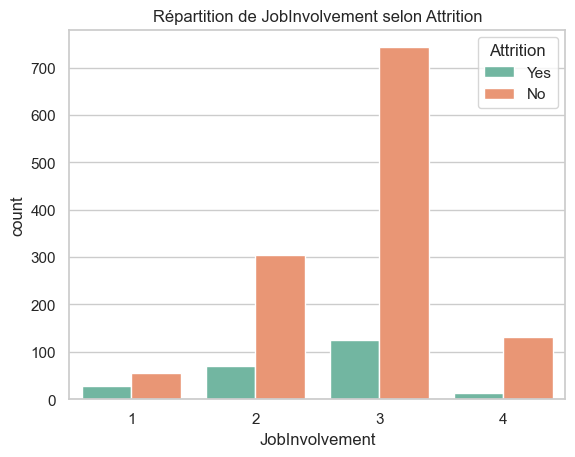

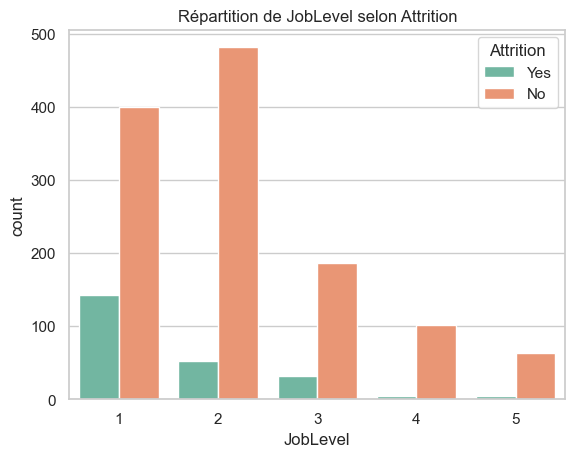

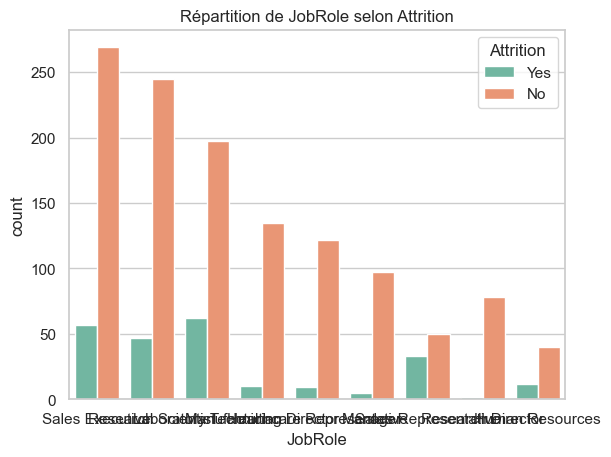

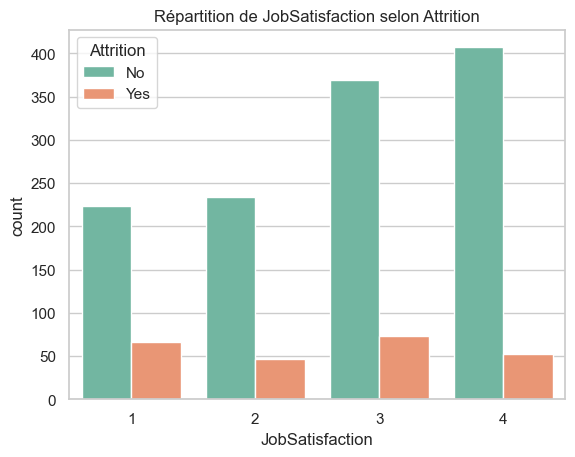

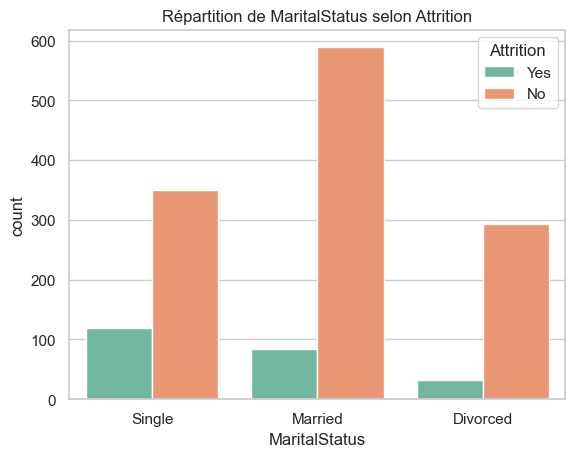

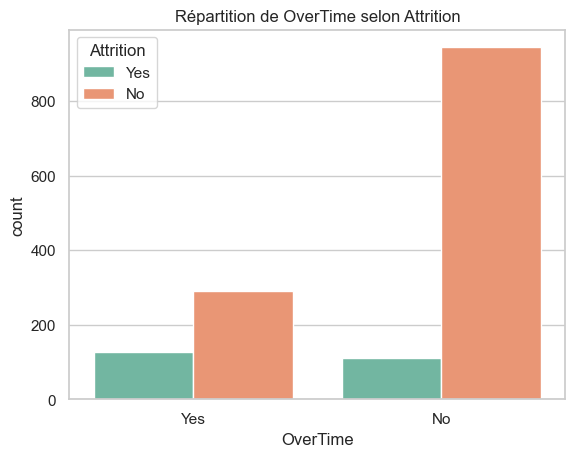

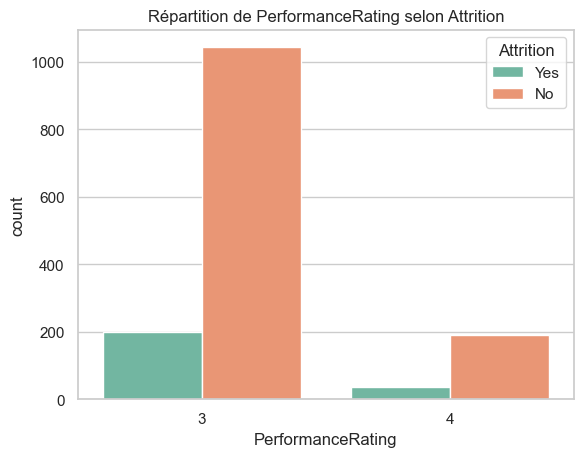

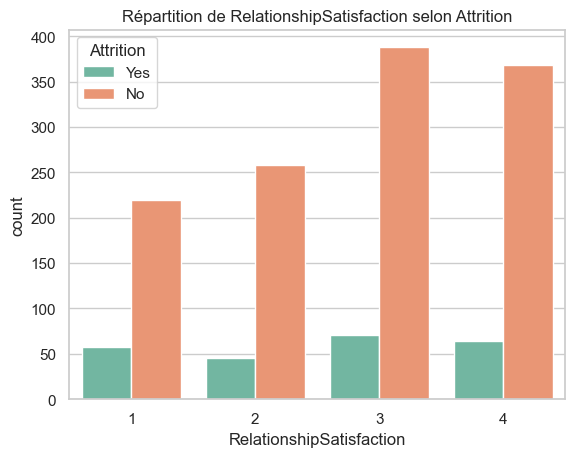

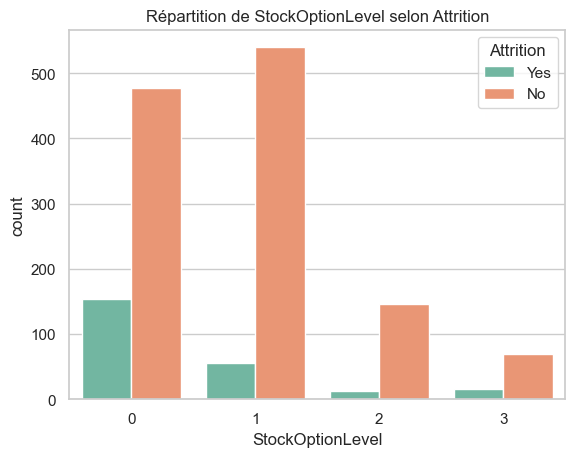

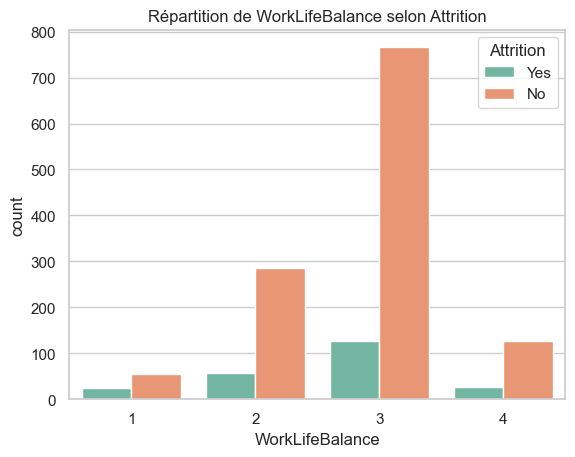

In [51]:
# Taraçage des des graphes pour tout les variables 
for col in catg_cols:
    plot_categ_count(data, col, target='Attrition')

### Corrélation et relation avec (Attrition) avec les variables numériques continues

In [52]:
# Encodage de la cible 

df_numeric['Attrition'] = data['Attrition'].map({'No':0, 'Yes':1})


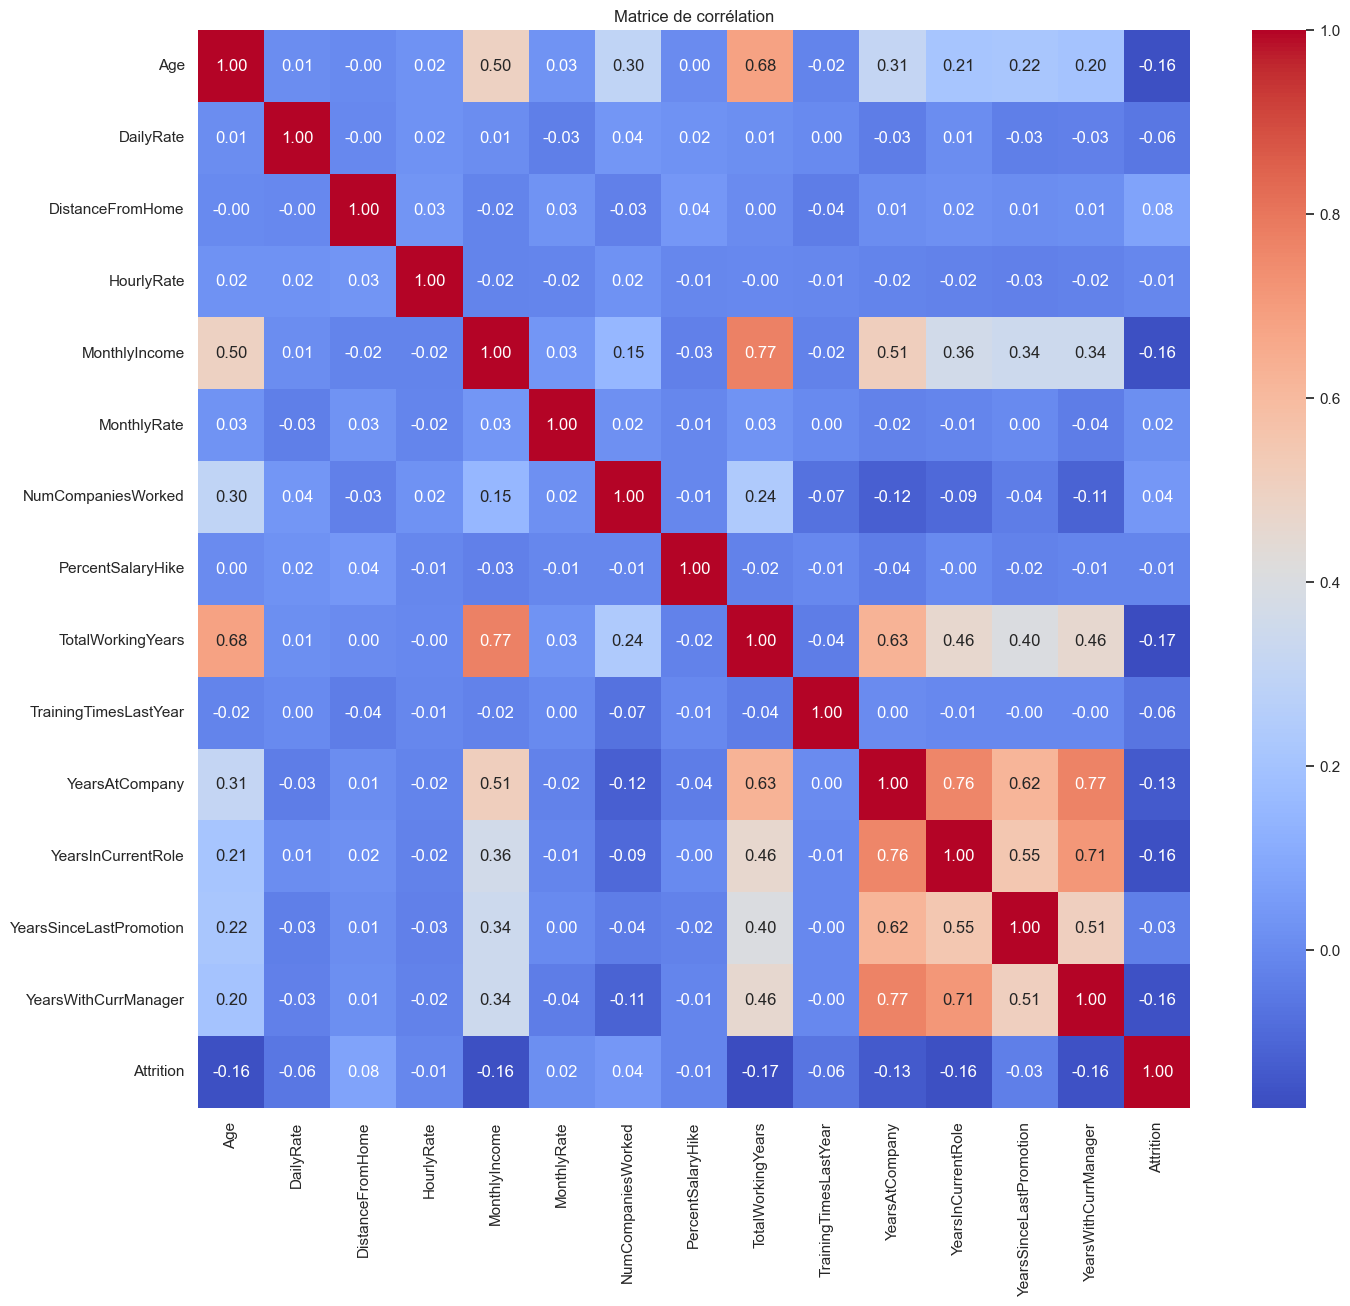

In [53]:
# Calcul de la corrélation  les variables numériques continues
corr_matrix = df_numeric.corr()
# Heatmap
plt.figure(figsize=(16,14))
sns.heatmap(corr_matrix,annot=True,fmt='.2f', cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.show()

D’après la matrice de corrélation, on observe que les variables numériques HourlyRate, MonthlyRate, NumCompaniesWorked, PercentSalaryHike et YearsSinceLastPromotion présentent une faible corrélation avec la variable cible, ce qui indique qu’elles n’ont pas d’influence significative sur celle-ci.

### Sélection des variables catégorielles à l’aide du test du Khi-deux

Le test du Khi-deux (χ²) a été utilisé afin d’identifier les variables catégorielles présentant une dépendance statistique avec la variable cible.  
Les variables dont la **p-value est inférieure à 0.05** sont considérées comme **significativement dépendantes** de la cible et ont été **retenues pour la phase de modélisation**, tandis que les autres ont été écartées.

In [64]:
from scipy.stats import chi2_contingency
def dependent_categorical_features(df,categorical_cols,target) :
    dependent_features = []
    
    for col in categorical_cols:
        if col != target:
            table = pd.crosstab(df[col], df[target])
            chi2, p, _, _ = chi2_contingency(table)

            if p < 0.05:
                dependent_features.append(col)

    return dependent_features

In [65]:
dependent_features = dependent_categorical_features(df_categ,catg_cols,'Attrition')
dependent_features

['BusinessTravel',
 'Department',
 'EducationField',
 'EnvironmentSatisfaction',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'OverTime',
 'StockOptionLevel',
 'WorkLifeBalance']

In [66]:
def independent_categorical_features(df,categorical_cols,target) :
    independent_features = []
    
    for col in categorical_cols:
        if col != target:
            table = pd.crosstab(df[col], df[target])
            chi2, p, _, _ = chi2_contingency(table)

            if p >= 0.05:
                independent_features.append(col)

    return independent_features

In [69]:
independent_catg_features = independent_categorical_features(df_categ,catg_cols,'Attrition')
independent_catg_features

['Education', 'Gender', 'PerformanceRating', 'RelationshipSatisfaction']

## Sélection des features numériques indépendantes avec le test ANOVA

In [72]:
from sklearn.feature_selection import f_classif
def independent_numerical_features(df,numeric_cols,target) :
    independent_features = []
    
    for col in numeric_cols:
        if col != target:
            table = pd.crosstab(df[col], df[target])
            _, p = f_classif(df[[col]], df[target])
        p = p[0]
        if p >= 0.05:
            independent_features.append(col)

    return independent_features

In [73]:
independent_num_features = independent_numerical_features(df_numeric,numeric_cols,'Attrition')
independent_num_features

['HourlyRate',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'YearsSinceLastPromotion']